PHASE 1: IMPORT LIBRARIES & LOAD DATA

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Suppress non-critical runtime warnings
warnings.filterwarnings("ignore")

# Load the raw dataset (preserves real-world extreme imbalance)
creditcard_data = pd.read_csv('creditcard.csv')

In [14]:
# Check total dataset size
print("Total rows loaded:", len(creditcard_data))

# Check unique values in the 'Class' column
print("Unique classes available:", creditcard_data['Class'].unique())

# Check the actual count of each class
print("Class counts:\n", creditcard_data['Class'].value_counts())

Total rows loaded: 284807
Unique classes available: [0 1]
Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64


PHASE 2: STRATIFIED DATA SPLITTING (Prevents Data Leakage)

In [15]:
# Separate independent structural features from the outcome target
X_full = creditcard_data.drop(columns='Class', axis=1)
y_full = creditcard_data['Class']

# Check for NaNs in the target and handle them before splitting
na_count = y_full.isna().sum()
print('NaNs in y_full:', na_count)
if na_count > 0:
    print('Dropping rows with missing target labels')
    mask = ~y_full.isna()
    X_full = X_full.loc[mask].reset_index(drop=True)
    y_full = y_full.loc[mask].reset_index(drop=True)

# Ensure target is integer (0/1) when appropriate
try:
    if set(np.unique(y_full)) <= {0, 1}:
        y_full = y_full.astype(int)
except Exception:
    pass


# Check class presence before moving forward
if len(np.unique(y_full)) < 2:
    raise ValueError("The dataset contains only one class! You cannot train a classifier without both fraud and legitimate examples.")

# Attempt stratified split
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
    )
except ValueError as e:
    print('Stratified split failed — falling back to non-stratified split:', e)
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_full, test_size=0.2, random_state=42
    )


print(f"Original Training shape: {X_train.shape}, Test shape: {X_test.shape}")
print('Original Training Class Distribution:', Counter(y_train))

NaNs in y_full: 0
Original Training shape: (227845, 30), Test shape: (56962, 30)
Original Training Class Distribution: Counter({0: 227451, 1: 394})


PHASE 3: FEATURE SCALING

In [16]:
# Fit and transform the scaler ONLY on the training data to prevent leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test set using the training metrics
X_test_scaled = scaler.transform(X_test)

PHASE 4: EXPERIMENT 1 - STANDARDIZED DOWN-SAMPLING (Under-sampling)

In [17]:
print("\n--- Running Experiment 1: Down-sampling ---")

train_df = pd.DataFrame(X_train_scaled, columns=X_full.columns)
train_df['Class'] = y_train.values

legit_train = train_df[train_df.Class == 0]
fraud_train = train_df[train_df.Class == 1]

# GUARDRAIL: Check if we have fraud samples to match
if len(fraud_train) == 0:
    print("CRITICAL: Zero fraud cases found in the training split. Skipping Experiment 1.")
    model_ds = None
    y_pred_ds, y_prob_ds = None, None
else:
    legit_downsampled = legit_train.sample(n=len(fraud_train), random_state=42)
    downsampled_train_df = pd.concat([legit_downsampled, fraud_train], axis=0)

    X_train_ds = downsampled_train_df.drop(columns='Class', axis=1)
    y_train_ds = downsampled_train_df['Class']

    print(f"Downsampled Training Class Distribution: {Counter(y_train_ds)}")

    model_ds = LogisticRegression(max_iter=1000)
    model_ds.fit(X_train_ds, y_train_ds)

    y_pred_ds = model_ds.predict(X_test_scaled)
    y_prob_ds = model_ds.predict_proba(X_test_scaled)[:, 1]

    print("\n[Down-sampling Test Performance]")
    print(classification_report(y_test, y_pred_ds))
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob_ds):.4f}")


--- Running Experiment 1: Down-sampling ---
Downsampled Training Class Distribution: Counter({0: 394, 1: 394})

[Down-sampling Test Performance]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962

ROC AUC Score: 0.9761


PHASE 5: EXPERIMENT 2 - SMOTE (Over-sampling)

In [18]:
print("\n--- Running Experiment 2: SMOTE Over-sampling ---")

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    get_ipython().system('pip install -q imbalanced-learn')
    from imblearn.over_sampling import SMOTE

minority_count = sum(y_train == 1)

# GUARDRAIL: Check if we have enough minority samples for SMOTE
if minority_count == 0:
    print("CRITICAL: Zero fraud cases found in training. SMOTE cannot run.")
    model_smote = None
    y_pred_sm, y_prob_sm = None, None
else:
    # Adjust neighbors dynamically if minority count is very low but non-zero
    k_neighbors = min(5, minority_count - 1) if minority_count > 1 else 1
    
    if minority_count == 1:
        print("WARNING: Only 1 minority class sample found. SMOTE requires neighbors; using manual duplication fallback.")
        # Simple duplication fallback if SMOTE is mathematically impossible
        X_train_smote = np.vstack([X_train_scaled, X_train_scaled[y_train == 1]])
        y_train_smote = pd.concat([y_train, y_train[y_train == 1]], ignore_index=True)
    else:
        sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_train_smote, y_train_smote = sm.fit_resample(X_train_scaled, y_train)

    print(f"SMOTE Training Class Distribution: {Counter(y_train_smote)}")

    model_smote = LogisticRegression(max_iter=1000)
    model_smote.fit(X_train_smote, y_train_smote)

    y_pred_sm = model_smote.predict(X_test_scaled)
    y_prob_sm = model_smote.predict_proba(X_test_scaled)[:, 1]

    print("\n[SMOTE Test Performance]")
    print(classification_report(y_test, y_pred_sm))
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob_sm):.4f}")


--- Running Experiment 2: SMOTE Over-sampling ---
SMOTE Training Class Distribution: Counter({0: 227451, 1: 227451})

[SMOTE Test Performance]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC AUC Score: 0.9708


PHASE 6: MODEL COMPARISON & VISUALIZATION

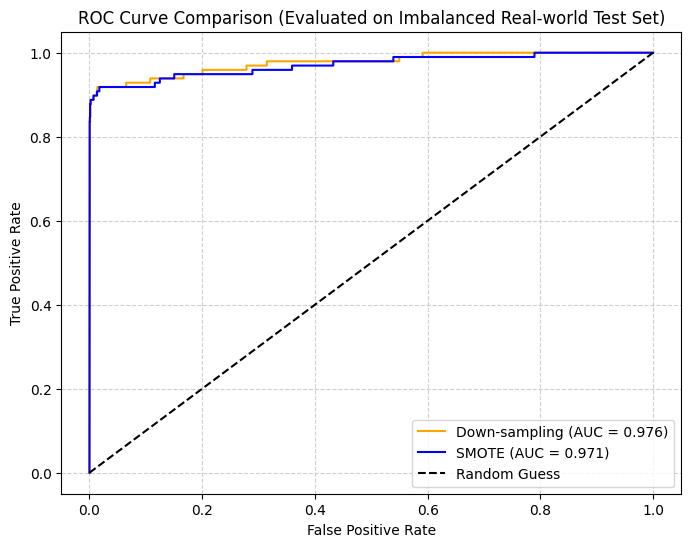

In [19]:
# Generate ROC curves data
fpr_ds, tpr_ds, _ = roc_curve(y_test, y_prob_ds)
fpr_sm, tpr_sm, _ = roc_curve(y_test, y_prob_sm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ds, tpr_ds, label=f'Down-sampling (AUC = {roc_auc_score(y_test, y_prob_ds):.3f})', color='orange')
plt.plot(fpr_sm, tpr_sm, label=f'SMOTE (AUC = {roc_auc_score(y_test, y_prob_sm):.3f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Evaluated on Imbalanced Real-world Test Set)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

ADDITIONAL VISUALS: Class distribution, correlations, histograms, PR and confusion matrices

Generating additional visuals...


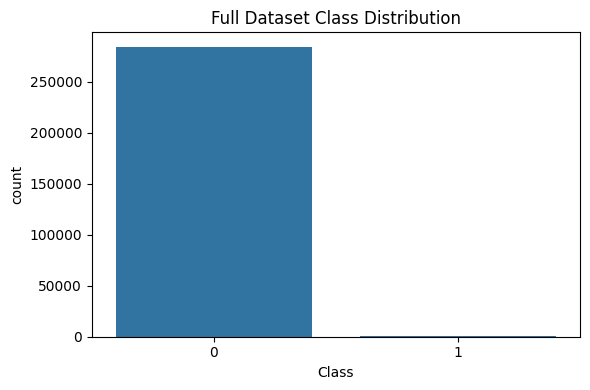

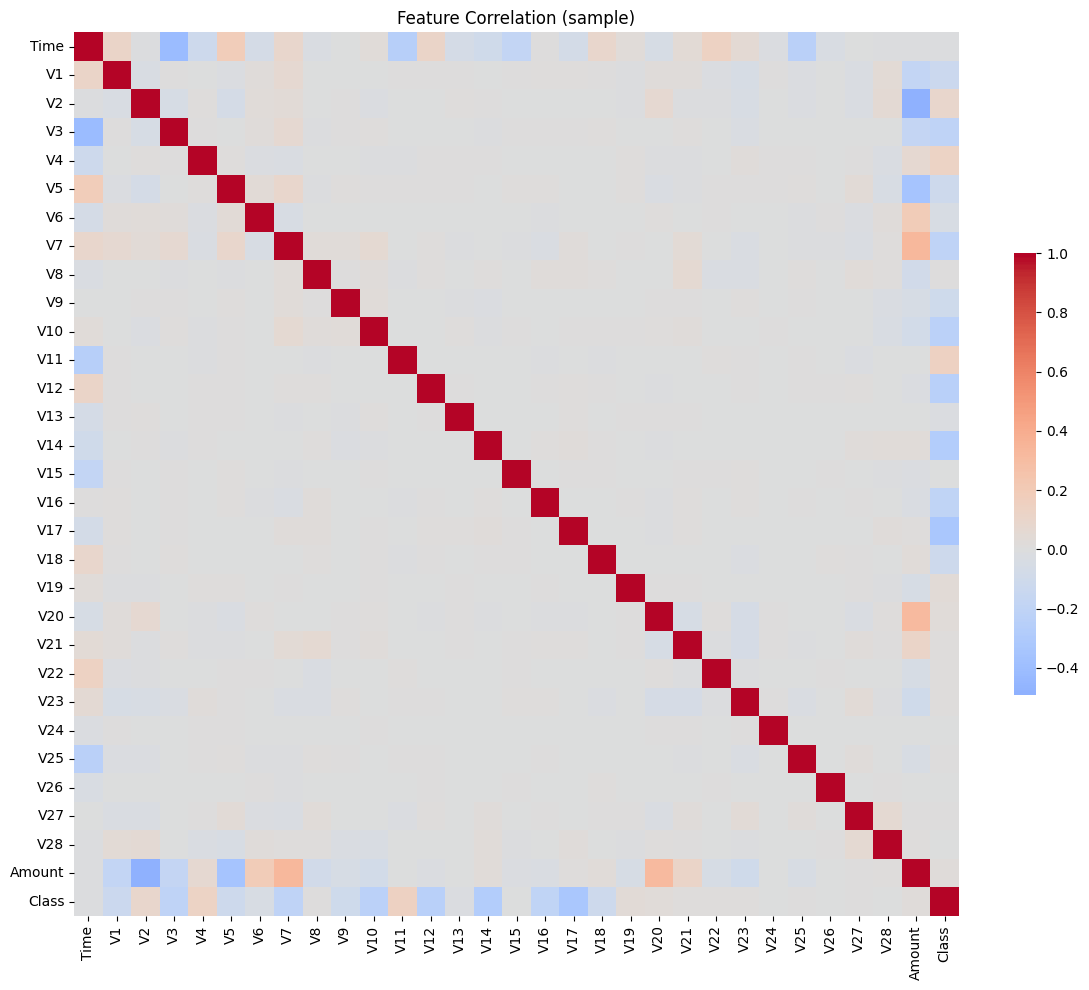

<Figure size 1400x800 with 0 Axes>

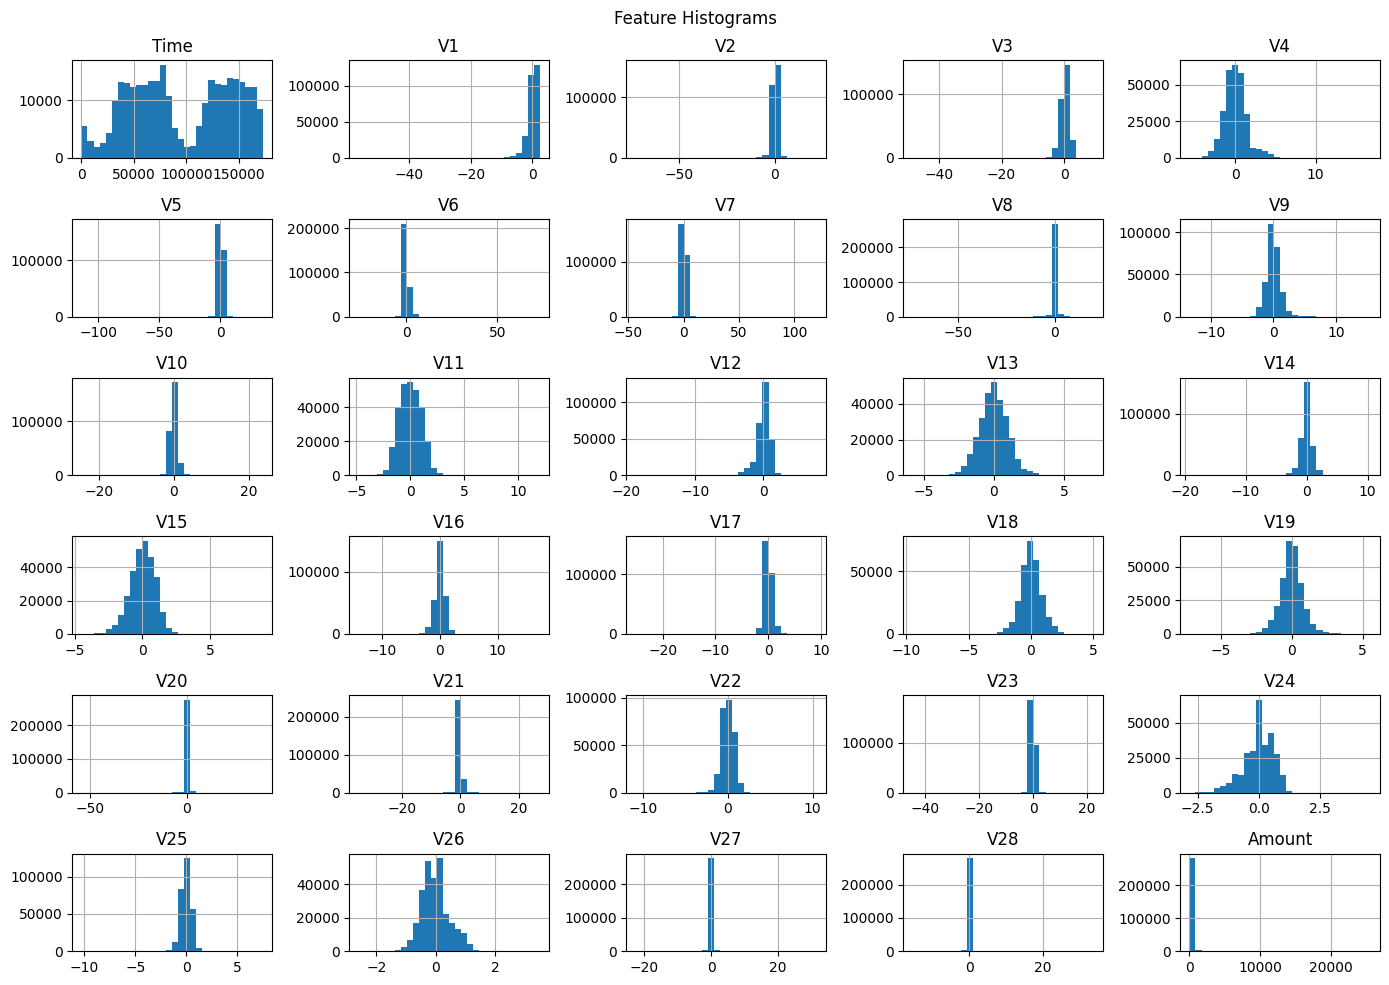

In [20]:
# Summary visuals added: distribution, correlation heatmap, histograms
print('Generating additional visuals...')
# Class distribution (full dataset)
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=creditcard_data).set_title('Full Dataset Class Distribution')
plt.tight_layout()
plt.show()
# Correlation heatmap (sampled for speed)
sample = creditcard_data.sample(frac=0.15, random_state=42) if len(creditcard_data) > 5000 else creditcard_data
plt.figure(figsize=(12,10))
sns.heatmap(sample.corr(), cmap='coolwarm', center=0, cbar_kws={'shrink': .5})
plt.title('Feature Correlation (sample)')
plt.tight_layout()
plt.show()
# Feature histograms (numeric features only)
plt.figure(figsize=(14,8))
numeric = creditcard_data.select_dtypes(include=[np.number]).drop(columns=['Class'], errors='ignore')
numeric.hist(bins=30, figsize=(14, int(max(2, len(numeric.columns)/3))))
plt.suptitle('Feature Histograms')
plt.tight_layout()
plt.show()

-- Downsample model metrics --


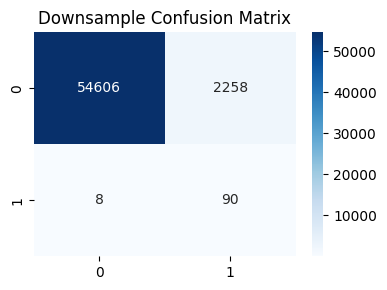

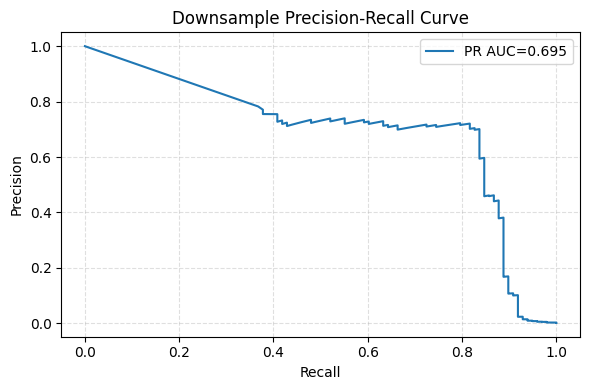



-- SMOTE model metrics --


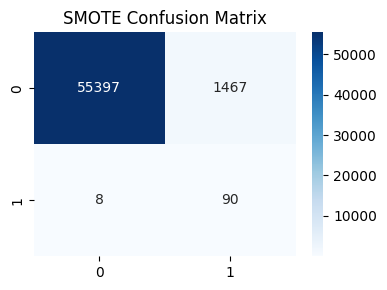

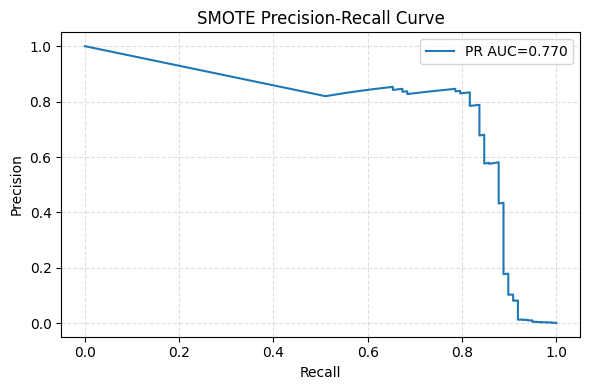

In [21]:
# Confusion matrices and Precision-Recall curves for both experiments
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc
# Prepare predictions and scores (already computed earlier in the notebook)
pairs = [('Downsample', y_test, y_pred_ds, y_prob_ds), ('SMOTE', y_test, y_pred_sm, y_prob_sm)]
for name, y_t, y_p, y_s in pairs:
    print(f'-- {name} model metrics --')
    try:
        cm = confusion_matrix(y_t, y_p)
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'{name} Confusion Matrix')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('Confusion matrix failed:', e)
    # Precision-Recall curve
    try:
        precision, recall, _ = precision_recall_curve(y_t, y_s)
        pr_auc = auc(recall, precision)
        plt.figure(figsize=(6,4))
        plt.plot(recall, precision, label=f'PR AUC={pr_auc:.3f}')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'{name} Precision-Recall Curve')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('PR curve failed:', e)
    print('\n')

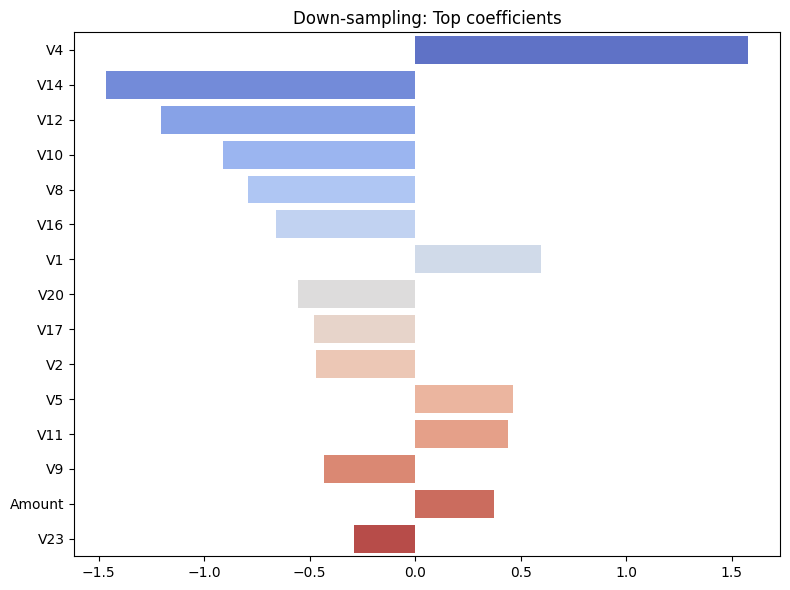

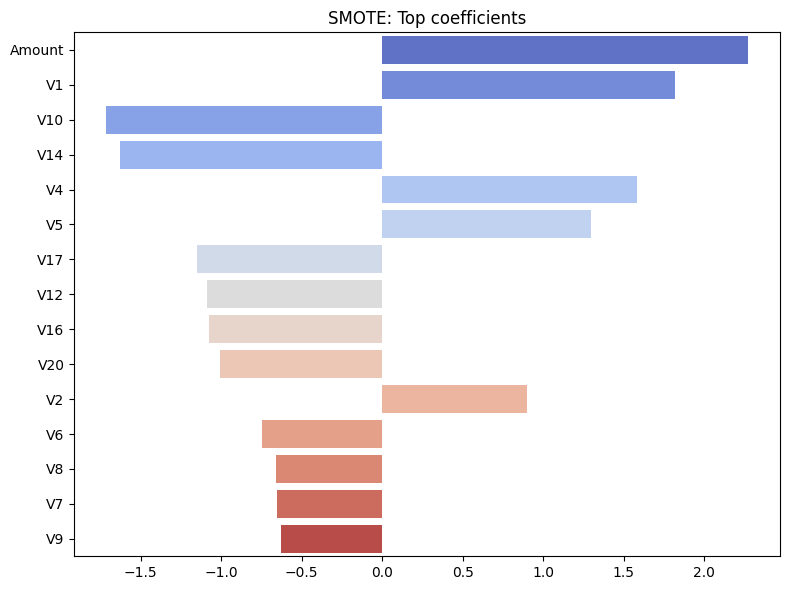

Additional visuals complete


In [22]:
# Top coefficients (absolute) for logistic models to show influential features
def plot_top_coeffs(model, X_cols, title):
    if not hasattr(model, 'coef_'):
        print(title + ': model has no coef_')
        return
    coef = model.coef_
    if coef.ndim > 1:
        coef = coef[0]
    imp = np.abs(coef)
    idx = np.argsort(imp)[::-1][:15]
    names = np.array(X_cols)[idx]
    vals = coef[idx]
    plt.figure(figsize=(8,6))
    sns.barplot(x=vals, y=names, palette='coolwarm')
    plt.title(title)
    plt.tight_layout()
    plt.show()
# Plot for both models if available
try:
    plot_top_coeffs(model_ds, X_full.columns, 'Down-sampling: Top coefficients')
except Exception as e:
    print('Down-sampling coefficients plot skipped:', e)
try:
    plot_top_coeffs(model_smote, X_full.columns, 'SMOTE: Top coefficients')
except Exception as e:
    print('SMOTE coefficients plot skipped:', e)
print('Additional visuals complete')

PHASE 7: EXPORT WINNING ARCHITECTURE

In [23]:
# Determine the model with the superior area under the curve dynamically
if y_prob_sm is not None and y_prob_ds is not None:
    if roc_auc_score(y_test, y_prob_sm) > roc_auc_score(y_test, y_prob_ds):
        best_model = model_smote
        filename = 'smote_logreg.joblib'
    else:
        best_model = model_ds
        filename = 'downsample_logreg.joblib'
elif y_prob_sm is not None:
    best_model = model_smote
    filename = 'smote_logreg.joblib'
elif y_prob_ds is not None:
    best_model = model_ds
    filename = 'downsample_logreg.joblib'
else:
    best_model = None
    filename = None
    print("\nCRITICAL: Neither model was trained successfully. Pipeline export aborted.")

if best_model is not None:
    joblib.dump({'model': best_model, 'scaler': scaler}, filename)
    print(f"\nSuccessfully saved the optimal pipeline configuration to: {filename}")


Successfully saved the optimal pipeline configuration to: downsample_logreg.joblib
